# Topic 1: SmartLend Initial EDA

Use this notebook to load the Give Me Some Credit dataset, inspect data quality, and produce the plots required in the lab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = "../data/raw/cs-training.csv"
df = pd.read_csv(DATA_PATH, index_col=0)

print(f"Shape: {df.shape}")
display(df.head())
display(df.dtypes)

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

## Data Quality Notes

Record missing values, target imbalance, unusual ranges, and anything that may affect preprocessing decisions in Topic 2.

In [3]:
display(df.describe())
print("Missing values per column:")
display(df.isnull().sum())
print("Target distribution:")
display(df["SeriousDlqin2yrs"].value_counts())
display(df["SeriousDlqin2yrs"].value_counts(normalize=True).round(3))

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Missing values per column:


SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Target distribution:


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64

## Target Distribution

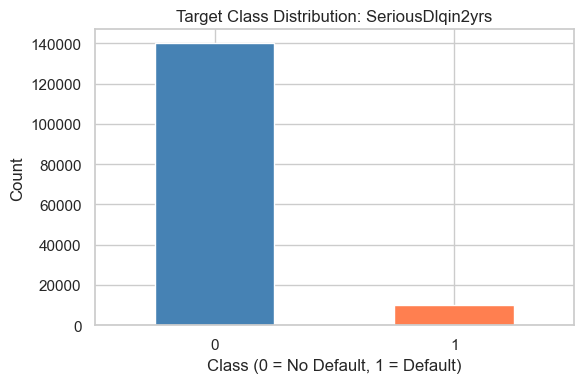

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
df["SeriousDlqin2yrs"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Class Distribution: SeriousDlqin2yrs")
ax.set_xlabel("Class (0 = No Default, 1 = Default)")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../docs/eda_target_distribution.png", dpi=150)
plt.show()

## Age and Income Distributions

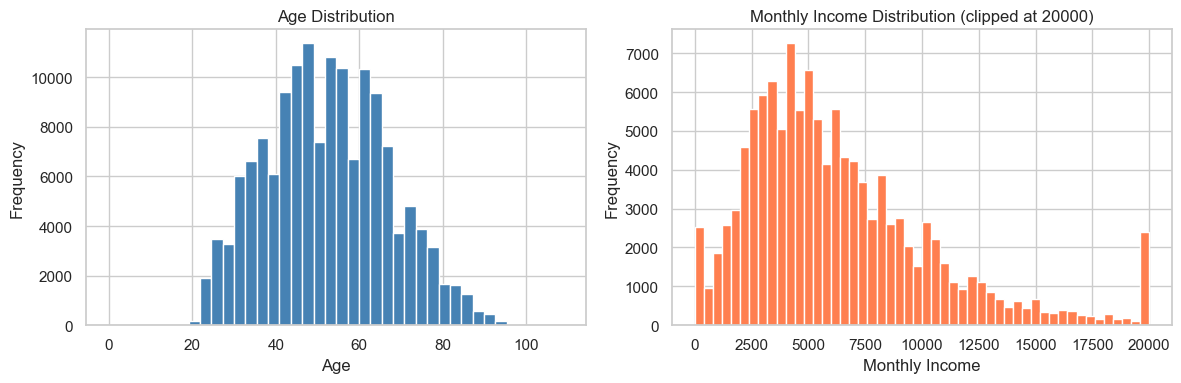

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["age"].plot(kind="hist", bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

df["MonthlyIncome"].dropna().clip(upper=20000).plot(kind="hist", bins=50, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Monthly Income Distribution (clipped at 20000)")
axes[1].set_xlabel("Monthly Income")

plt.tight_layout()
plt.savefig("../docs/eda_age_income.png", dpi=150)
plt.show()

## Ratio Features

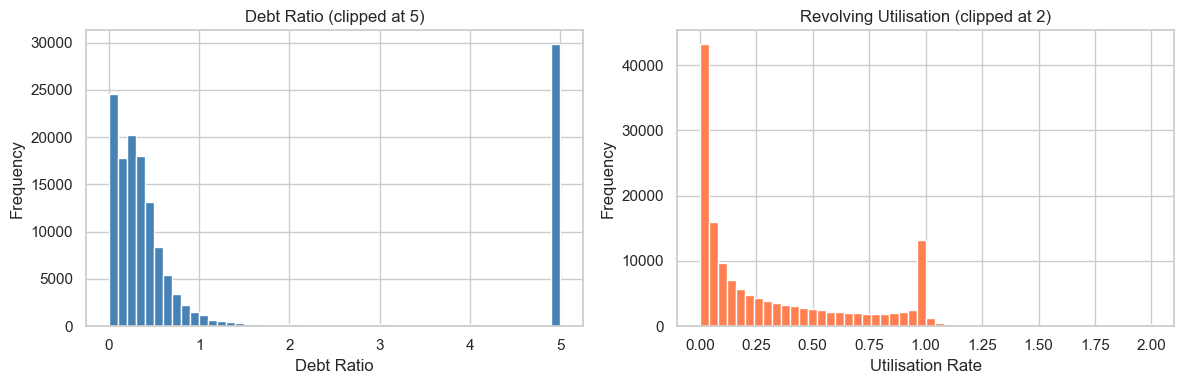

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["DebtRatio"].clip(upper=5).plot(kind="hist", bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Debt Ratio (clipped at 5)")
axes[0].set_xlabel("Debt Ratio")

df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=2).plot(kind="hist", bins=50, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Revolving Utilisation (clipped at 2)")
axes[1].set_xlabel("Utilisation Rate")

plt.tight_layout()
plt.savefig("../docs/eda_ratios.png", dpi=150)
plt.show()

## Correlation Overview

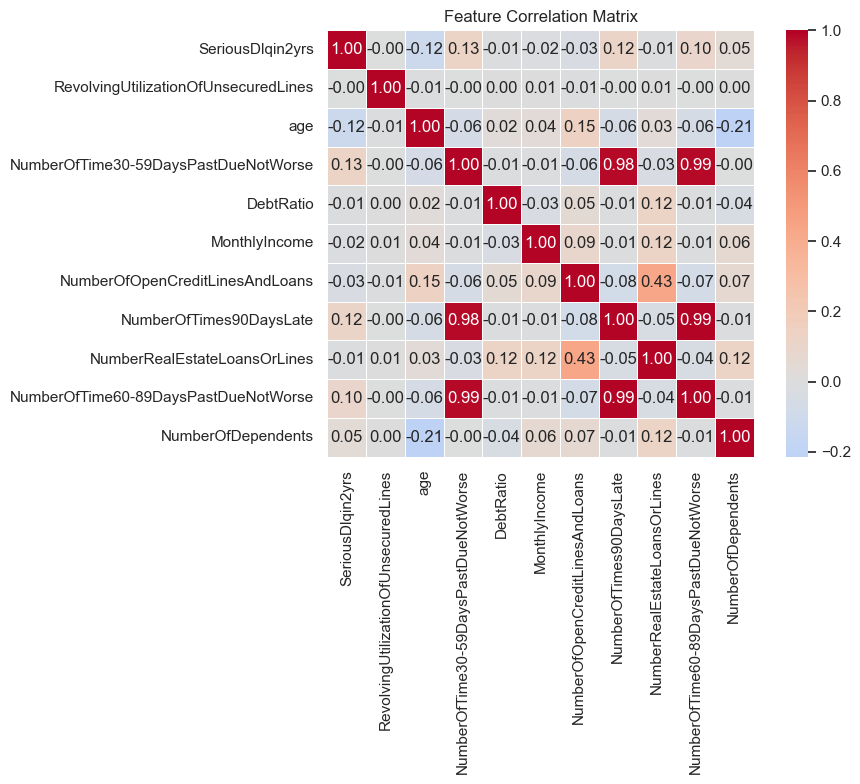

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../docs/eda_correlation.png", dpi=150)
plt.show()